In [1]:
import mne
from mne.time_frequency import tfr_morlet, stft
import numpy as np
import matplotlib as plt
import pywt
import h5py
from temporaldata import Data
from pathlib import Path
import gc
import pandas as pd
import re


from io import StringIO
from mne.channels import generate_2d_layout


import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize


In [2]:
SOURCE = r"/capstor/store/cscs/swissai/a0091/processed/neurosoft_monkeys_2026_v2"

# SOURCE = r"/capstor/store/cscs/swissai/a0091/processed/neurosoft_minipigs_2026"

In [3]:
path = Path(SOURCE + "/sub-01_ses-03_task-AcousStim_acq-RH_desc-raw.h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

In [4]:
keep_channels = data.channels.type == "ecog"
ch_names = data.channels.id[keep_channels].tolist()
ecog_data = data.ecog.signal[:, keep_channels].T

sfreq = 2000

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='ecog')
raw = mne.io.RawArray(ecog_data, info)

raw.set_eeg_reference('average', projection=False)
raw.notch_filter(freqs=[50, 100, 150])
# raw.filter(l_freq=0.5, h_freq=200)

filtered_data = raw.get_data()

Creating RawArray with float64 data, n_channels=29, n_times=2837600
    Range : 0 ... 2837599 =      0.000 ...  1418.800 secs
Ready.
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 s)



In [5]:
trials = data.on_vs_off_trials
starts = trials.start
ends = trials.end
labels = trials.behavior_labels
ids = trials.behavior_ids
id_to_label = dict(zip(ids, labels))

print(np.unique(labels))

['off' 'on']


In [73]:
label_map = {'off': 1, 'on': 2}  # adjust once you've confirmed label strings above
event_id = {'off': 1, 'on': 2}

labels_str = np.array([str(l).lower() for l in labels])
event_codes = np.array([label_map[l] for l in labels_str])

durations = ends - starts
epoch_len = durations.min()
print(f"Using fixed epoch length: {epoch_len:.3f} s (shortest trial)")

onset_samples = (starts * sfreq).astype(int)
events = np.column_stack([onset_samples,
                           np.zeros(len(onset_samples), dtype=int),
                           event_codes])

epochs = mne.Epochs(raw, events, event_id=event_id,
                     tmin=0, tmax=epoch_len,
                     baseline=None, preload=True)
print(epochs)

Using fixed epoch length: 0.500 s (shortest trial)
Not setting metadata
2754 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2754 events and 1001 original time points ...
850 bad epochs dropped
<Epochs | 1904 events (all good), 0 – 0.5 s (baseline off), ~421.7 MiB, data loaded,
 'off': 945
 'on': 959>


In [74]:
csv_path = "/capstor/store/cscs/swissai/a0091/data/nsb-monkeys-v1.1/sub-01/ses-01/ieeg/sub-01_ses-01_acq-RH_electrodes.tsv"

df = pd.read_csv(Path(csv_path), sep="\t")


df = df[df['x'].notna() & df['y'].notna() & df['z'].notna()]

names = df["name"].tolist()



print(names)
xy = df[["x", "y"]].to_numpy()
 
# w, h are the size (in normalized 0-1 layout units) of each little topo axis.
# pad is the margin around the whole grid. normalize=True rescales xy into
# the unit box for you, using your original coords for relative spacing.
layout = generate_2d_layout(
    xy,
    w=0.05,
    h=0.05,
    pad=0.05,
    ch_names=names,
    name="SG3D1",
    normalize=True,
)
 
print(layout)
print("box:", layout.box)
print("pos shape:", layout.pos.shape)
print("first 3 rows of pos (x, y, w, h):")
print(layout.pos[:3])


['SG3D1E8', 'SG3D1E22', 'SG3D1E16', 'SG3D1E9', 'SG3D1E2', 'SG3D1E23', 'SG3D1E17', 'SG3D1E10', 'SG3D1E3', 'SG3D1E24', 'SG3D1E18', 'SG3D1E11', 'SG3D1E4', 'SG3D1E25', 'SG3D1E26', 'SG3D1E5', 'SG3D1E12', 'SG3D1E19', 'SG3D1E27', 'SG3D1E6', 'SG3D1E13', 'SG3D1E20', 'SG3D1E28', 'SG3D1E7', 'SG3D1E14', 'SG3D1E21', 'SG3D1E29', 'SG3D1E15', 'SG3D1E1']
<Layout | SG3D1 - Channels: SG3D1E8, SG3D1E22, SG3D1E16 ...>
box: (0, 0, np.float64(0.12975609756097567), np.float64(0.185546875))
pos shape: (29, 4)
first 3 rows of pos (x, y, w, h):
[[0.        0.625     0.05      0.05     ]
 [0.        1.        0.05      0.05     ]
 [0.1395122 0.78125   0.05      0.05     ]]


In [75]:
fmin, fmax = 1, 200
epochs.drop_bad()

psd_on = epochs['on'].compute_psd(method='welch', fmin=fmin, fmax=fmax)
psd_off = epochs['off'].compute_psd(method='welch', fmin=fmin, fmax=fmax)



# psd_on.plot_topo(layout=layout)

Effective window size : 0.500 (s)
Effective window size : 0.500 (s)


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_106197/2584789578.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_on.plot()


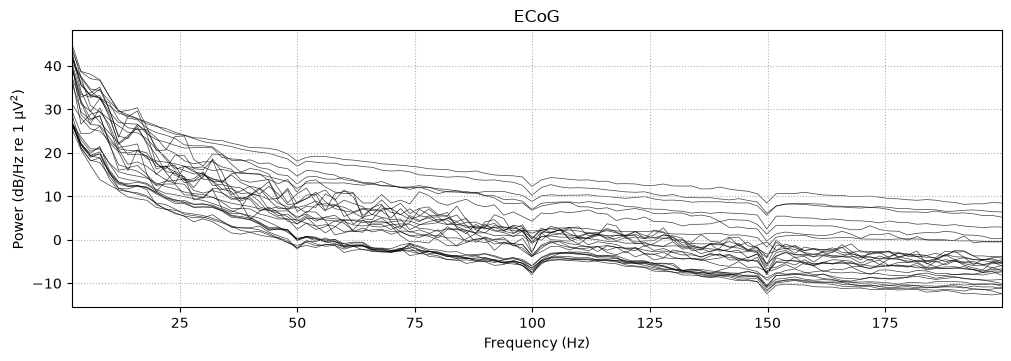

In [76]:
psd_on.plot()

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_106197/322951741.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_off.plot()


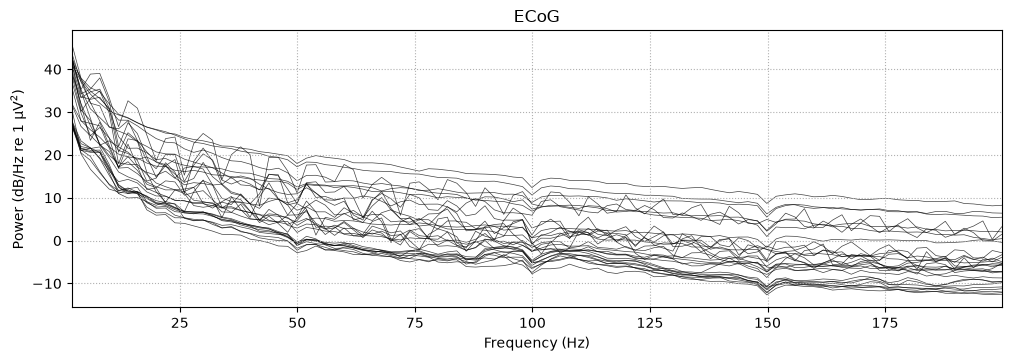

In [77]:
psd_off.plot()

In [ ]:
from mne.stats import permutation_cluster_test

on_avg_ch = on_data.mean(axis=1)
off_avg_ch = off_data.mean(axis=1)

T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    [on_avg_ch, off_avg_ch], n_permutations=1000, tail=0, seed=42
)

sig_clusters = [c for c, p in zip(clusters, cluster_p_values) if p < 0.05]
print(f"{len(sig_clusters)} significant cluster(s)")
for c in sig_clusters:
    idx = c[0]
    print(f"  {freqs[idx][0]:.1f}-{freqs[idx][-1]:.1f} Hz")

Using a threshold of 3.925834
stat_fun(H1): min=6.1955812581395555e-06 max=5.558434539804479
Running initial clustering …
Found 1 cluster


/tmp/ipykernel_24120/3465418528.py:6: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
/capstor/scratch/cscs/awgolab/mila_test/auditorydecoding/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| Permuting : 999/999 [00:00<00:00, 13706.52it/s]

0 significant cluster(s)


In [32]:
stim_trials = data.acoustic_stim_trials
stim_starts = np.asarray(stim_trials.start)
stim_ends = np.asarray(stim_trials.end)
stim_labels = stim_trials.behavior_labels
stim_ids = stim_trials.behavior_ids
stim_id_to_label = dict(zip(stim_ids, stim_labels))

print(np.unique(stim_labels))  # check format, e.g. '500' vs '500Hz' vs numeric

def parse_freq(lbl):
    match = re.search(r'(\d+(?:\.\d+)?)', str(lbl))
    return float(match.group(1)) if match else np.nan

stim_freqs = np.array([parse_freq(l) for l in stim_labels])

on_starts = starts[labels_str == 'on']

on_freqs = []
for s in on_starts:
    match = np.where((stim_starts <= s) & (stim_ends >= s))[0]
    if len(match) == 0:
        match = [np.argmin(np.abs(stim_starts - s))]
    on_freqs.append(stim_freqs[match[0]])

on_freqs = np.array(on_freqs)
print(pd.Series(on_freqs).value_counts())

['stim_1000Hz' 'stim_8000Hz' 'stim_800Hz']
1000.0    237
800.0     197
8000.0    128
Name: count, dtype: int64


In [34]:
epochs_on = epochs['on'].copy()
epochs_on.metadata = pd.DataFrame({'stim_freq': on_freqs})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs, off_data.mean(axis=(0, 1)), 'k--', linewidth=2, label='Off (baseline)')

for f in sorted(np.unique(on_freqs)):
    sub = epochs_on[epochs_on.metadata['stim_freq'] == f]
    psd_f = sub.compute_psd(method='welch', fmin=fmin, fmax=fmax)
    ax.plot(freqs, psd_f.get_data().mean(axis=(0, 1)), label=f'On @ {f:g} Hz')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
ax.legend()
ax.set_title('PSD by stimulation frequency vs Off')
plt.show()

ValueError: metadata must have the same number of rows (562) as events (58)